# Smooth SVM
Smooth SVMs solve the following optimization problem:
$$
  \min_{\mathbf{\beta} \in \mathbb{R}^d} \
  C \sum_{i=1}^n V(y_i \mathbf{\beta}^\intercal \mathbf{x}_i) + \frac{1}{2} \| \mathbf{\beta} \|_2^2
$$
where $\mathbf{x}_i \in \mathbb{R}^d$ is a feature vector, $y_i \in \{-1, 1\}$ is a binary label, and  $V(·)$ is the smoothed hinge loss (shown here with a default smoothing parameter τ=1):
$$
  V(z) = \begin{cases}
  0 & \text{if } z \ge 1 \\
  \frac{(1-z)^2}{2} & \text{if } 0 < z < 1 \\
  \frac{1}{2}- z & \text{if } z \le 0
  \end{cases}
$$


> **Note.** Since the smooth hinge loss is a plq function, we can optimize it using `rehline.plq_Ridge_Classifier`. 
> Moreover, this wrapper adapts the `plqERM_Ridge` into a classifier, compatible with the scikit-learn API.

In [ ]:
## install rehline
%pip install rehline -q

In [2]:
## set up plotting style
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = ["#FFE4E1", "#3D325C"]
sns.set_palette(custom_palette)

In [3]:
## simulate data
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

n, d = 10000, 5
X, y = make_classification(n_samples=n, n_features=d, random_state=42)
y = 2 * y - 1
X = scaler.fit_transform(X)

In [4]:
## solve Smooth SVM via `plq_Ridge_Classifier`
from rehline import plq_Ridge_Classifier

clf = plq_Ridge_Classifier(loss={"name": "sSVM"}, C=1.0)
clf.fit(X=X, y=y)

plq_Ridge_Classifier(loss={'name': 'sSVM'})

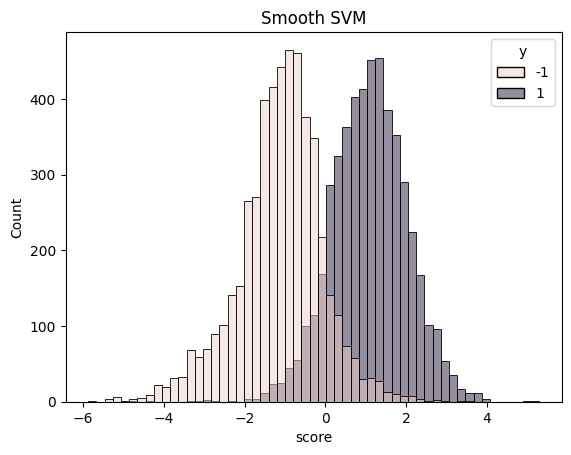

In [5]:
import warnings

import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

score = clf.decision_function(X)
df = pd.DataFrame({"score": score, "y": y})
sns.histplot(df, x="score", hue="y").set_title("Smooth SVM")
plt.show()

## With Pipeline
`plq_Ridge_Classifier` can be integrated into a scikit-learn Pipeline to streamline preprocessing including scaling.

In [6]:
## simulate data
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

n, d = 10000, 5
X, y = make_classification(n_samples=n, n_features=d, random_state=42)
y = 2 * y - 1

In [7]:
## solve SVM via `plq_Ridge_Classifier`
from rehline import plq_Ridge_Classifier

pipe = Pipeline([("scaler", StandardScaler()), ("clf", plq_Ridge_Classifier(loss={"name": "sSVM"}, C=1.0))])
pipe.fit(X=X, y=y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', plq_Ridge_Classifier(loss={'name': 'sSVM'}))])

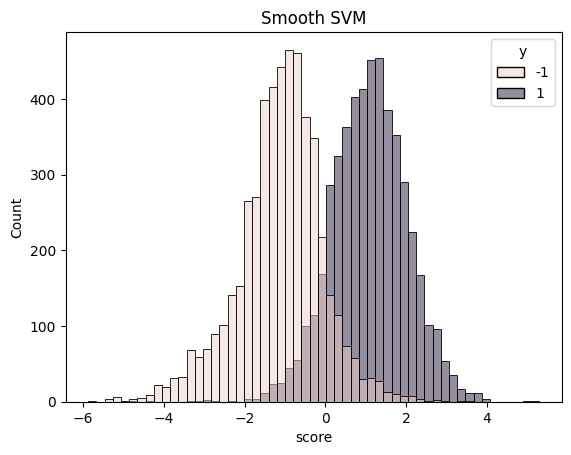

In [8]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

score = pipe.decision_function(X)
df = pd.DataFrame({"score": score, "y": y})
sns.histplot(df, x="score", hue="y").set_title("Smooth SVM")
plt.show()

## Hyperparameter Tuning with GridSearchCV

Due to its compatibility with the scikit-learn API, `GridSearchCV` can be applied to determine the optimal hyperparameters for the ReHLine model.

In [9]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {"clf__C": [0.1, 1.0, 10.0]}

# Create the GridSearchCV object
grid_search = GridSearchCV(pipe, param_grid, cv=5)
grid_search.fit(X, y)

# Print the best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'clf__C': 0.1}
Best CV Accuracy: 0.8920


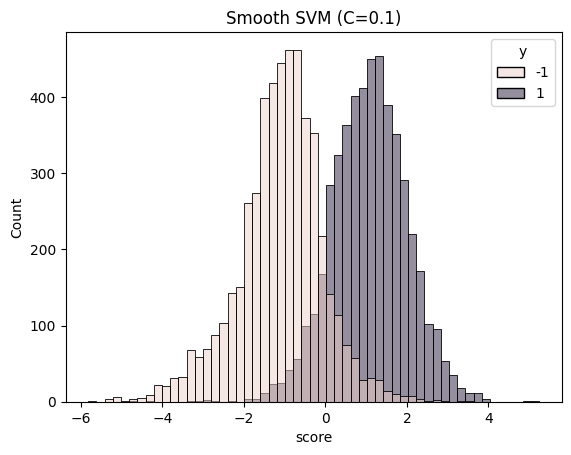

In [10]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

score = grid_search.decision_function(X)
df = pd.DataFrame({"score": score, "y": y})
sns.histplot(data=df, x="score", hue="y").set_title("Smooth SVM (C=0.1)")
plt.show()